# WILDFIRE RISK AND SEVERITY ANALYSIS

## BUSINESS UNDERSTANDING

### Project Problem Statement
Wildfires can cause serious damage to forests, property, and human life. Understanding the weather and environmental conditions that influence wildfire occurrence and severity can help improve preparation and response efforts to reduce wildfire risk and damage.

## Project Objective:
To explore environmental conditions that influence wildfire occurrence and severity. 

### Project Goal:
Understand how temperature, humidity, wind, and rainfall affect wildfire risk. 
Identify patterns that can support better wildfire preparedness and response.

## DATA UNDERSTANDING

Here, I explored the dataset to understand what it contains and check its quality before cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading And Preview Of The Dataset 

In [2]:
df = pd.read_csv("../data/forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [3]:
df = pd.read_csv("../data/forestfires.csv")
df.tail()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


In [7]:
df.shape

(517, 13)

#### Dataset Structure

In [6]:
df.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

#### Checking For Missing Values

In [5]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

#### Understanding Variables In The Dataset

| Column | Meaning |
|---|---|
| X | x-axis spatial coordinate of the forest fire location |
| Y | y-axis spatial coordinate of the forest fire location |
| month | month the fire incident occurred |
| day | day of the week the fire incident occurred |
| FFMC | Fine Fuel Moisture Code- Tells how dry the surface materials are.  |
| DMC | Duff Moisture Code- measures the dryness in shallow soil layers |
| DC | Drought Code- measures long term drought conditions |
| ISI | Initial Spread Index- estimates how fast fire spreads after ignition. |
| temp | temperature in °C |
| RH | relative humidity (%) |
| wind | wind speed |
| rain | rainfall amount |
| area | burned forest area |

#### Data Overview

The dataset has 517 rows and 13 columns. It includes both categorical and numerical variables related to forest fire conditions, weather, and burned area.The dataset appears structured and suitable for analysis.

#### Dataset Observation

- The dataset is clean and well-structured.
- No missing values were found.
- Most variables are numerical.
- 'month' and 'day' are categorical variables.
- 'Burned area' appears to be the main variable of interest for analysis.

## DATA PREPARATION

Checking for duplicates

In [3]:
import pandas as pd
df = pd.read_csv("../data/forestfires.csv")
df.duplicated().sum()

np.int64(4)

In [8]:
# Displaying The Original and duplicated rows
df[df.duplicated(keep=False)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


#### Duplicate Check

A total of 4 duplicate rows were identified in the dataset. Since these rows were exact copies of existing records, they were removed to improve data quality and prevent duplicate observations from affecting the analysis.

In [4]:
# Removing duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [18]:
df_cleaned.to_csv("cleaned_forestfires.csv", index=False)

In [10]:
# Recomfirming For Missing Values

df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [11]:
# Checking For Inconsistencies in Categorical Columns
# For Day
df["day"].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

In [12]:
# For Month
df["month"].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [14]:
# Fixing Month Ordering
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

In [15]:
# Fixing Day Ordering
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df["day"] = pd.Categorical(df["day"], categories=day_order, ordered=True)

#### Checking Categorical Columns

I checked the categorical columns using their unique values to make sure there were no spelling or formatting issues. The month and day columns were consistent, so I converted them into ordered categories to keep their correct calendar order during analysis.

In [19]:
# Saving Copy of Cleaned Dataset
df_cleaned = df.copy()

#### Cleaned Dataset

A cleaned copy of the dataset was created and saved as "df_cleaned" for use in the next stage of analysis.

## Understanding The Target Variable

In this section, I examined the `area` column, which shows the total burned area caused by each fire. Since this is the value the model will predict, I checked its distribution and looked for extreme values before moving to modeling.

In [20]:
df['area'].describe()

count     513.000000
mean       12.891598
std        63.892586
min         0.000000
25%         0.000000
50%         0.540000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

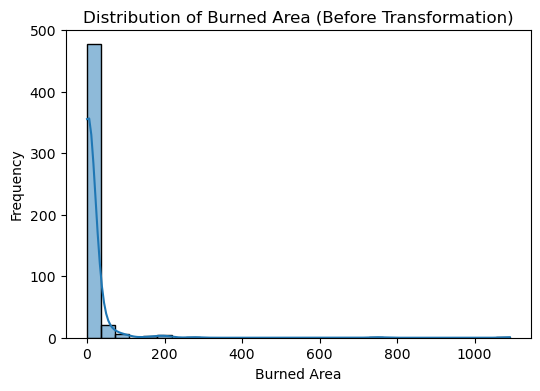

In [21]:
# Visualization of Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['area'], bins=30, kde=True)
plt.title('Distribution of Burned Area (Before Transformation)')
plt.xlabel('Burned Area')
plt.ylabel('Frequency')
plt.show()

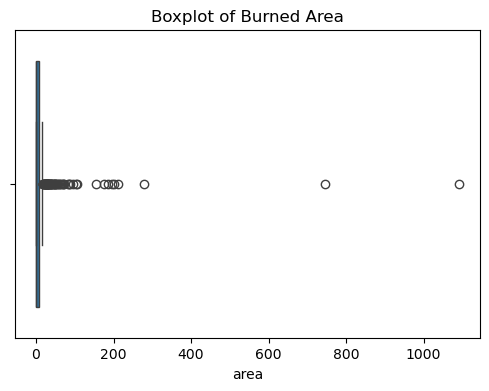

In [22]:
# Checking For Outliers (Extreme Values that deviate significantly from the rest of a dataset in a distribution)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['area'])
plt.title('Boxplot of Burned Area')
plt.show()

In [23]:
# Inspecting Skewness Of Burnt Area

df["area"].skew()

np.float64(12.802213419146321)

#### Skewness in Burned Area

The area column is heavily skewed to the right, with a skewness value of 12.80. This means most fires burned only small areas, while a few spread across much larger areas.

#### Burned Area Distribution Assessment

The burned area column was examined in more detail because it is the main variable being predicted in this project.

In [24]:
# Finding records with zero burned area
(df["area"] == 0).sum()

np.int64(244)

In [25]:
# Most frequent values in the area column
df["area"].value_counts().head()

area
0.00     244
1.94       3
1.46       2
9.96       2
11.06      2
Name: count, dtype: int64

#### Observation 

The burned area column contains many zero values, and most of the remaining values are relatively small compared to the few large ones.

#### Separation of Burned Area Into Groups

To better understand the nature of zero burned area records, the dataset is divided into:
- Fire events with no recorded burned area (`area = 0`)
- Fire events with measurable burned area (`area > 0`)

In [26]:
# Sectionining Of Area Column Into Groups
zero_area = df[df['area'] == 0]
non_zero_area = df[df['area'] > 0]

print("Zero area count:", len(zero_area))
print("Non-zero area count:", len(non_zero_area))

Zero area count: 244
Non-zero area count: 269


In [31]:
# Target Variable Log Transformation
import numpy as np

df_cleaned['area_log'] = np.log1p(df_cleaned['area'])

In [32]:
# Updating Cleaned Dataset With Newly added Column(area_log)

df_cleaned.to_csv('cleaned_forestfires.csv', index=False)

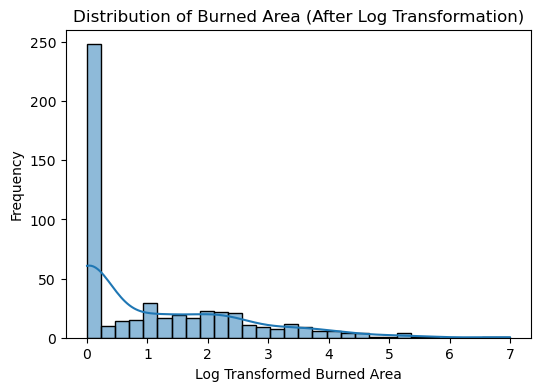

In [33]:
# Visualizing Transformed Target Variable

plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['area_log'], bins=30, kde=True)
plt.title('Distribution of Burned Area (After Log Transformation)')
plt.xlabel('Log Transformed Burned Area')
plt.ylabel('Frequency')
plt.show()

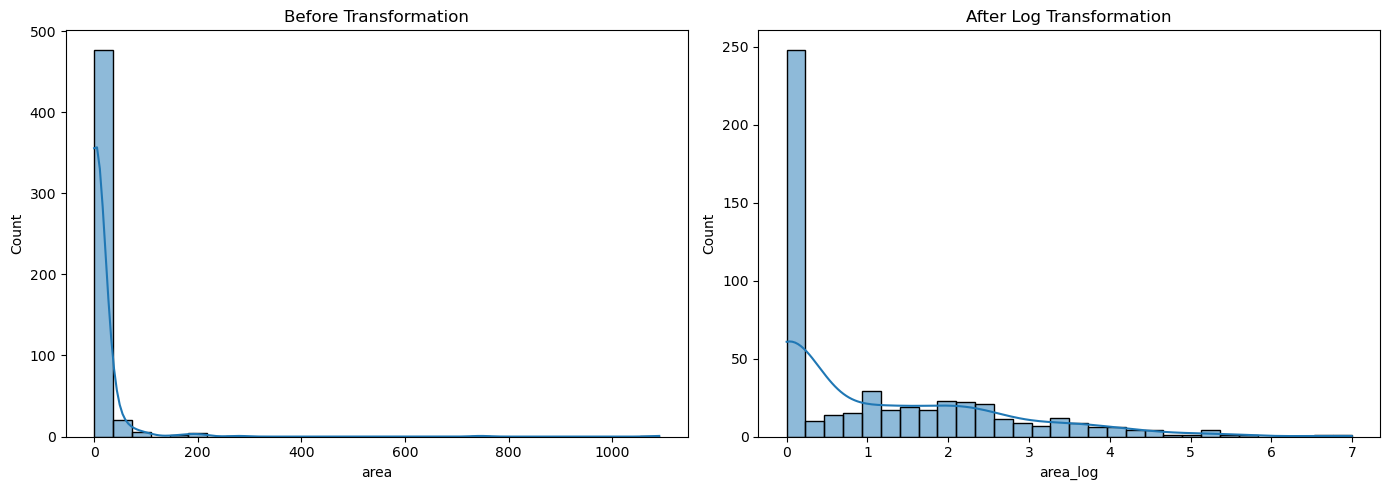

In [36]:
# Comparison of the before and after of the target Variable
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['area'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Before Transformation')

sns.histplot(df_cleaned['area_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('After Log Transformation')

plt.tight_layout()
plt.show()

#### Preparing the Target Variable

The area column was heavily skewed, with many small values and a few very large ones. This made the distribution uneven and could affect model performance.

To reduce this skewness and limit the effect of extreme values, I applied a log transformation (log1p) to the area column.

This made the distribution more balanced and better suited for further analysis and modeling.

In [37]:
# LOADING UPDATED CLEANED DATASET

import pandas as pd

df_cleaned = pd.read_csv('cleaned_forestfires.csv')
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0


## EXPLORATORY DATA ANALYSIS

### Relationship Between Weather Variables and Fire Indices

This section looks at how environmental factors are related to fire weather indices. It is done to help understand the following questions:

Does temperature affect FFMC?
Does humidity Infuence DMC and reduce wildfire risk?
Does rainfall have an impact on DC and reset dryness?
Does wind speed Increase Fire spread (ISI)?

This is to see if these weather conditions have any relationship with fire behaviour, and to help with building a model that can predict whether a fire will be small or large.

Environmental_variables = ['temp', 'RH', 'rain', 'wind']
Fire_indices = ['FFMC', 'DMC', 'DC', 'ISI']

### Q1: Does Temperature(Heat) Affect FFMC

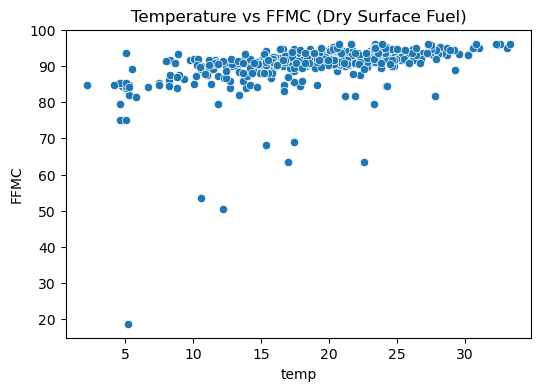

In [38]:
# Plotting Temperature Against FFMC
plt.figure(figsize=(6,4))
sns.scatterplot(x='temp', y='FFMC', data=df)
plt.title('Temperature vs FFMC (Dry Surface Fuel)')
plt.show()

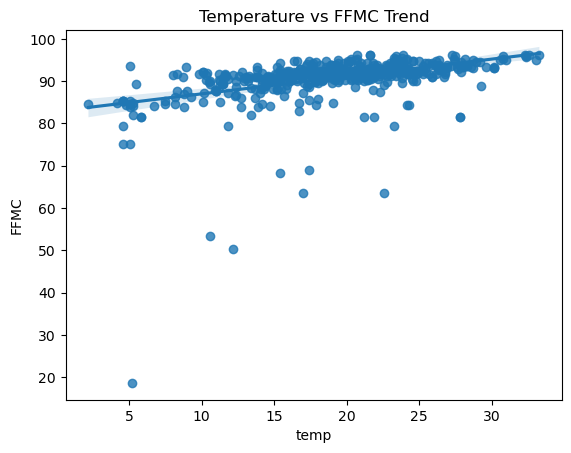

,temp,FFMC
temp,1.000000,0.431609
FFMC,0.431609,1.000000


In [39]:
# Adding Trend line
sns.regplot(x='temp', y='FFMC', data=df)
plt.title('Temperature vs FFMC Trend')
plt.show()

# Checking the correlation between the 2 variables
df[['temp', 'FFMC']].corr()

There is a moderate positive relationship (r = 0.43) between temperature and FFMC. This means that when temperature increases, FFMC also tends to increase. However, the relationship is not strong, as other weather factors like humidity, rainfall, and wind also play an important role in influencing FFMC.

### Q2: Does Relative humidity(Moisture in the air) Influence DMC?

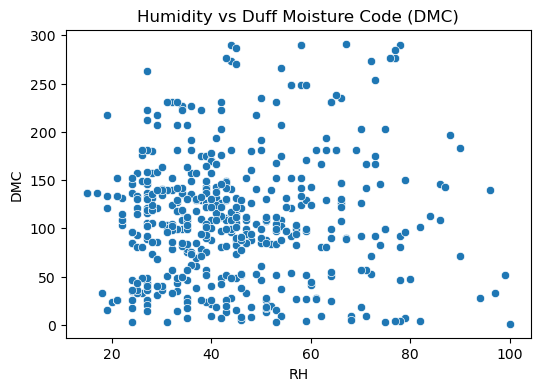

In [48]:
# Plotting Relative Humdity Against DMC
plt.figure(figsize=(6,4))
sns.scatterplot(x='RH', y='DMC', data=df)
plt.title('Humidity vs Duff Moisture Code (DMC)')
plt.show()

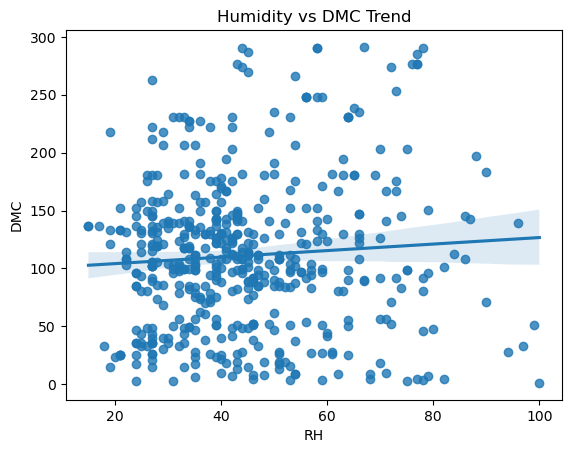

,RH,DMC
RH,1.000000,0.071711
DMC,0.071711,1.000000


In [40]:
# Adding Trend line
sns.regplot(x='RH', y='DMC', data=df)
plt.title("Humidity vs DMC Trend")
plt.show()

# Checking the correlation between the 2 variables
df[['RH', 'DMC']].corr()

### Q3: Does rainfall have an impact on DC and reset dryness?

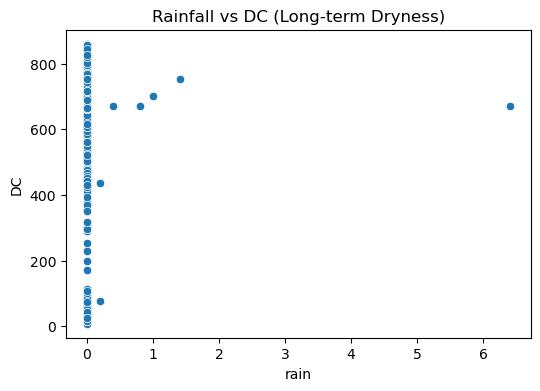

In [47]:
# Plotting Rainfall Against DC
plt.figure(figsize=(6,4))
sns.scatterplot(x='rain', y='DC', data=df)
plt.title('Rainfall vs DC (Long-term Dryness)')
plt.show()

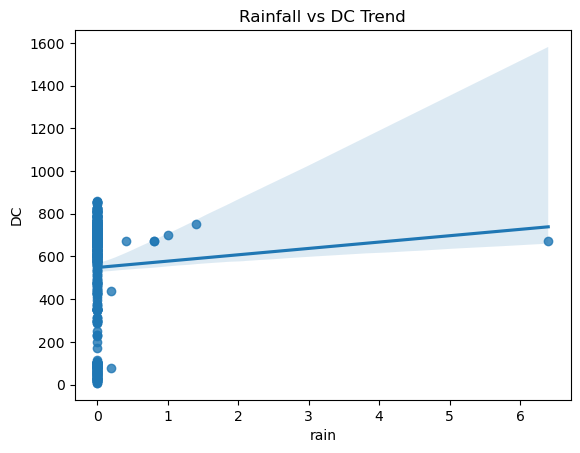

,rain,DC
rain,1.00000,0.03569
DC,0.03569,1.00000


In [46]:
# Adding Trend line
sns.regplot(x='rain', y='DC', data=df)
plt.title('Rainfall vs DC Trend')
plt.show()

# Checking the correlation between the 2 variables
df[['rain', 'DC']].corr()

### Q4: Does wind speed Increase Fire spread (ISI)?

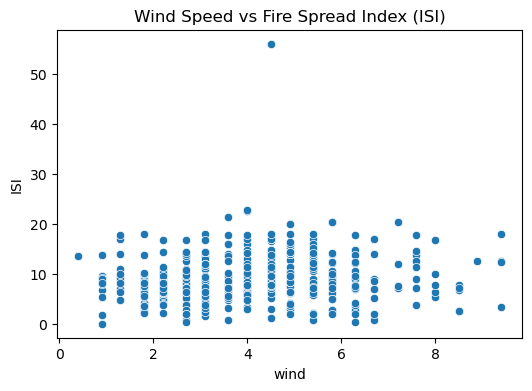

In [45]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='wind', y='ISI', data=df)
plt.title('Wind Speed vs Fire Spread Index (ISI)')
plt.show()

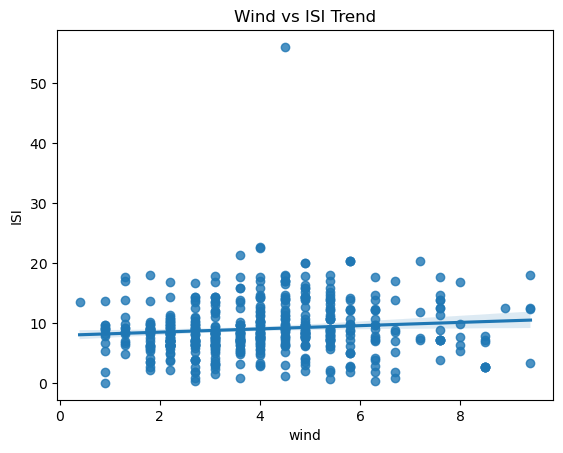

,wind,ISI
wind,1.000000,0.106825
ISI,0.106825,1.000000


In [42]:
sns.regplot(x='wind', y='ISI', data=df)
plt.title('Wind vs ISI Trend')
plt.show()

df[['wind', 'ISI']].corr()

In [6]:
results = pd.DataFrame({
    "Relationship": [
        "Temperature → FFMC",
        "Humidity → DMC",
        "Rain → DC",
        "Wind → ISI"
    ],
    "Expected Effect": [
        "Positive",
        "Negative",
        "Negative",
        "Positive"
    ]
})

results

,Relationship,Expected Effect
0,Temperature → FFMC,Positive
1,Humidity → DMC,Negative
2,Rain → DC,Negative
3,Wind → ISI,Positive


### Fire Weather Indices and Environmental Variables

This section examines how weather conditions influence the fire weather indices used to assess wildfire risk.

### Correlation Heatmap

This was used to explore relationships between environmental variables and fire indices.

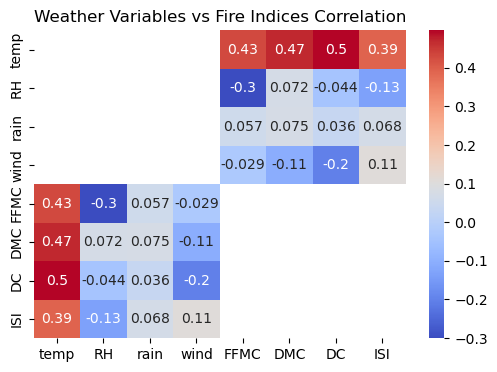

In [49]:
selected_cols = ['temp', 'RH', 'rain', 'wind', 'FFMC', 'DMC', 'DC', 'ISI']
corr = df[selected_cols].corr()
import numpy as np

weather = ['temp', 'RH', 'rain', 'wind']
indices = ['FFMC', 'DMC', 'DC', 'ISI']

mask = np.zeros_like(corr, dtype=bool)

for i in corr.index:
    for j in corr.columns:
        if (i in weather and j in weather) or (i in indices and j in indices):
            mask[corr.index.get_loc(i), corr.columns.get_loc(j)] = True

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask)
plt.title("Weather Variables vs Fire Indices Correlation")
plt.show()

### Comparison Of Relationship Between Temperature And Fire 

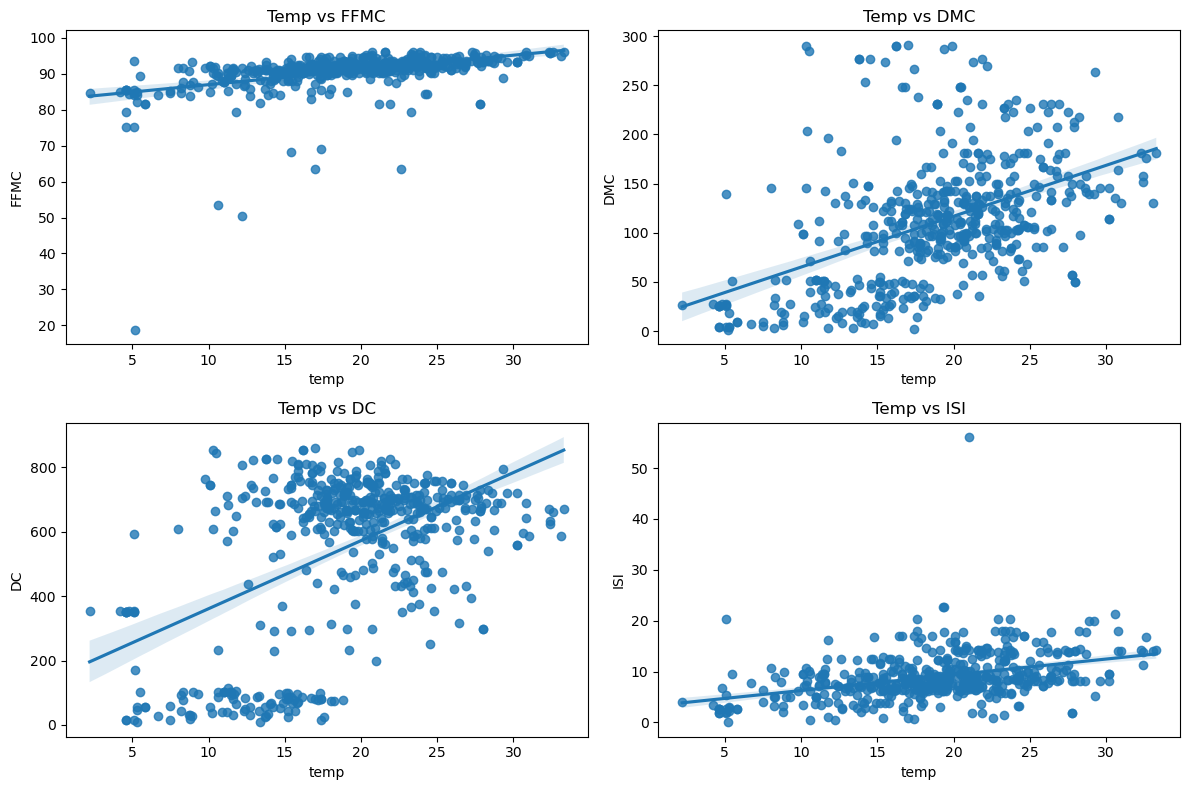

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.regplot(x='temp', y='FFMC', data=df, ax=axes[0,0])
axes[0,0].set_title('Temp vs FFMC')

sns.regplot(x='temp', y='DMC', data=df, ax=axes[0,1])
axes[0,1].set_title('Temp vs DMC')

sns.regplot(x='temp', y='DC', data=df, ax=axes[1,0])
axes[1,0].set_title('Temp vs DC')

sns.regplot(x='temp', y='ISI', data=df, ax=axes[1,1])
axes[1,1].set_title('Temp vs ISI')

plt.tight_layout()
plt.show()

This helped to see that temperature has more consistent relationships with the fire indices compared to other weather variables.  Since temperature showed the most consistent relationships, further analysis focused on Temperature vs FFMC, DMC, DC and ISI.

#### Insight 

The scatter plots show that temperature has a positive relationship with all fire weather indices. As temperature increases, FFMC, DMC, DC, and ISI generally increase. However, the strength of the relationship varies across the indices. The relationship appears strongest with FFMC and DMC, while ISI shows a weaker and more scattered pattern. This suggests that temperature plays an important role in fuel dryness and fire behaviour, especially in surface and mid-layer conditions.

### Exploring Environmental Variables Relationship With Burned Area

The goal is to identify whether these weather conditions show any visible pattern with how much land gets burned (area).

#### Temperature vs Burned Area

Are higher temperatures linked with larger wildfire burned areas?

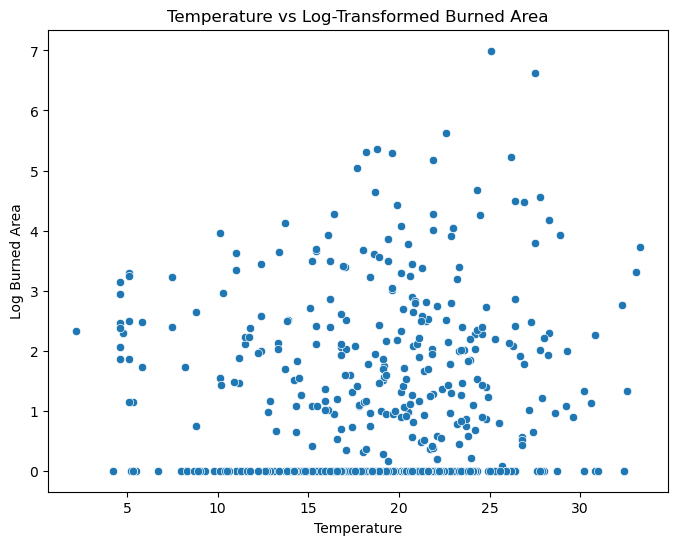

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='temp', y='area_log')
plt.title('Temperature vs Log-Transformed Burned Area')
plt.xlabel('Temperature')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot suggests a weak positive relationship between temperature and burned area. Most wildfire events are concentrated around lower burned area values, meaning many fires remained relatively small. However, a few larger wildfire events appear more often at moderate to higher temperatures, suggesting that warmer conditions may be linked to larger wildfires. 

#### Insight

This suggests that temperature may influence wildfire spread, as warmer conditions may support larger fires. The use of the log-transformed burned area also helps reduce the effect of extreme wildfire events, making the overall relationship clearer and easier to analyze.

#### Humidity vs Burned Area

Do humidity levels influence wildfire burned area?

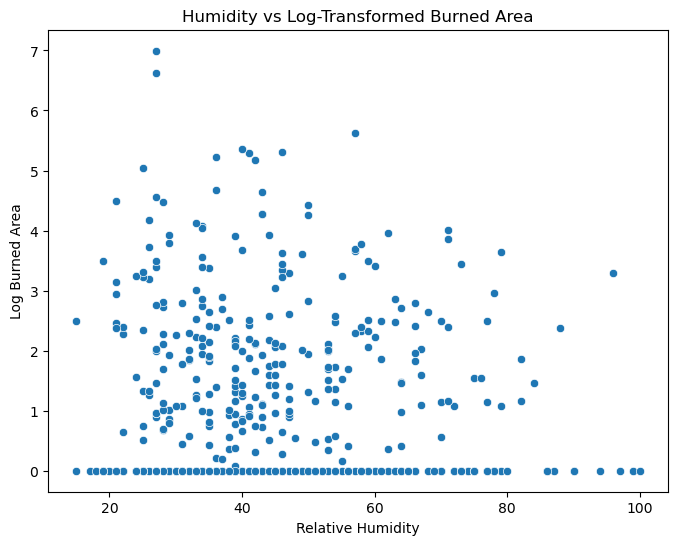

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='RH', y='area_log')
plt.title('Humidity vs Log-Transformed Burned Area')
plt.xlabel('Relative Humidity')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a slight negative relationship between humidity and burned area. Wildfire events are mostly clustered around smaller burned areas, even across different humidity levels. Still, a few larger fires appear when humidity is lower, which suggests that drier air may be linked to wider wildfire spread.

#### Insight

This suggests that humidity may influence wildfire area size, especially under drier conditions. Lower humidity can make vegetation lose moisture more easily, which may allow fires to spread faster. Although, humidity alone does not explain wildfire size, which means other factors likely also contribute to how much land gets burned. 

#### Wind vs Burned Area

Does wind speed influence wildfire burned area?

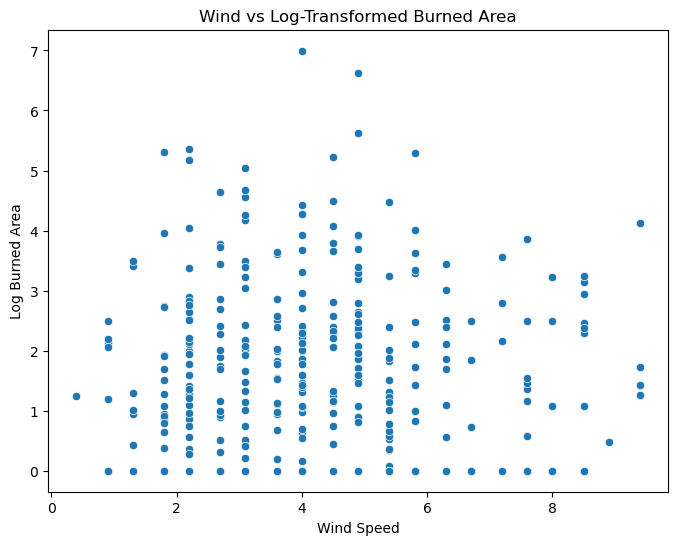

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='wind', y='area_log')
plt.title('Wind vs Log-Transformed Burned Area')
plt.xlabel('Wind Speed')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a weak relationship between wind speed and log-transformed burned area. Wildfire events are mostly clustered around lower burned area values across different wind speeds, meaning many fires remained relatively small. A few larger wildfire events appear at moderate wind speeds, which indicates that wind may support wildfire spread under certain conditions.

#### Insight

Wind speed may influence how quickly wildfires spread, especially when conditions are favorable for fire movement. However, the pattern in the chart also shows that wind alone is not enough to explain wildfire size, since many wildfire events still remained small across different wind speeds.

## Rainfall vs Burned Area

Can Rainfall influence wildfire burned area?

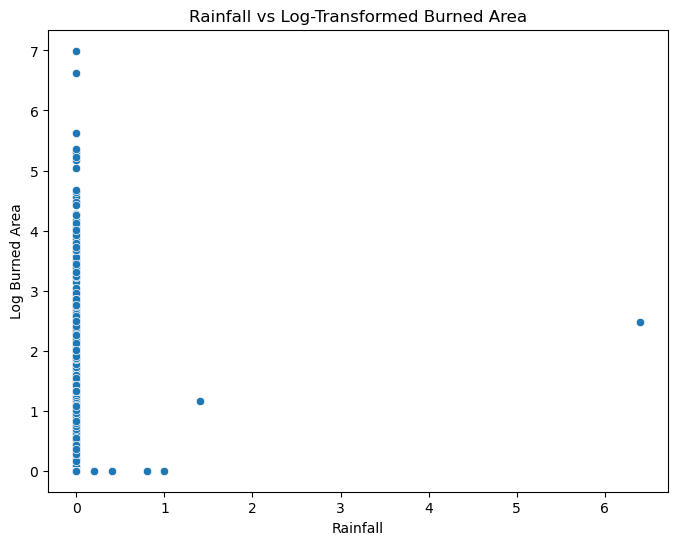

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='rain', y='area_log')
plt.title('Rainfall vs Log-Transformed Burned Area')
plt.xlabel('Rainfall')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a very weak relationship between rainfall and log-transformed burned area. Most wildfire events occurred under little or no rainfall, while burned area values still varied across these conditions. The points are widely spread, making the relationship less clear and showing that rainfall alone does not strongly explain wildfire burned area in the dataset.

#### Insight

Most wildfire events in the dataset happened during low rainfall conditions. However, both small and larger wildfire events still occurred when rainfall was low, which shows that rainfall alone is not enough to explain wildfire burned area. Other environmental factors likely also affect how much land gets burned.

### Fire Weather Indices Overview On Burned Area

#### Comparison of Fire Weather Conditions

To better understand the records with zero burned area, fire weather conditions were compared between observations with no burned area and those with recorded burned area. This helps to check whether both groups were exposed to similar environmental conditions and whether the zero values are meaningful for further analysis.

The fire weather indices (FFMC, DMC, DC, and ISI) describe how favorable the conditions are for fire ignition and spread, regardless of the final burned area.

In [86]:
indices = ['FFMC', 'DMC', 'DC', 'ISI']

comparison = df.groupby(df['area'] == 0)[indices].mean()
comparison.index = ['Non-Zero Area', 'Zero Area']

comparison

,FFMC,DMC,DC,ISI
Non-Zero Area,91.031599,115.001115,572.688848,9.182156
Zero Area,90.202869,106.566393,523.210246,8.848770


Fire weather indices were compared between zero burned area records and non-zero burned area records.

The results show that both groups have similar values, although the non-zero burned area group is slightly higher across most indices. This suggests that fires with and without burned area often occur under similar weather conditions.

Overall, this supports keeping the zero burned area records in the dataset, since they still occur under similar fire weather conditions 

## Distribution Comparison of Fire Weather Indices

Boxplots was used to visually compare fire weather conditions between zero and non-zero burned area events.

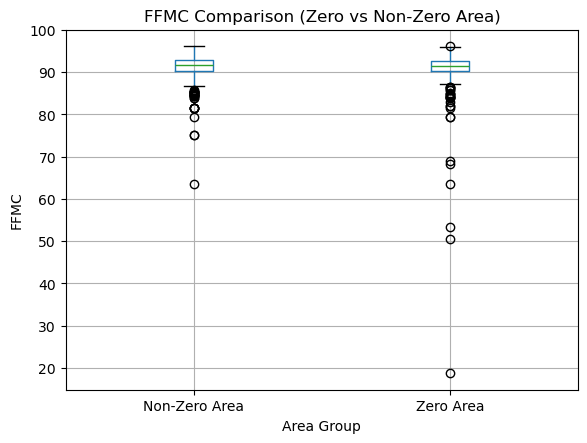

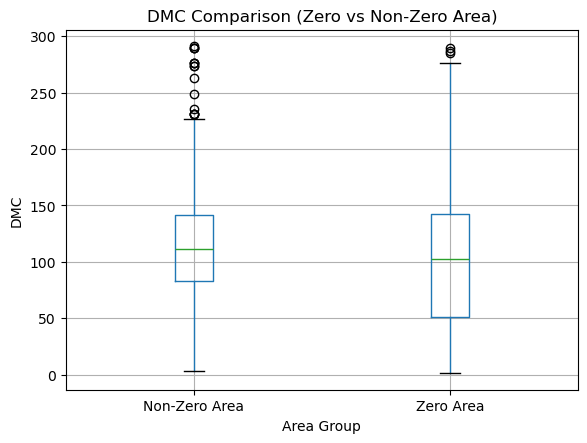

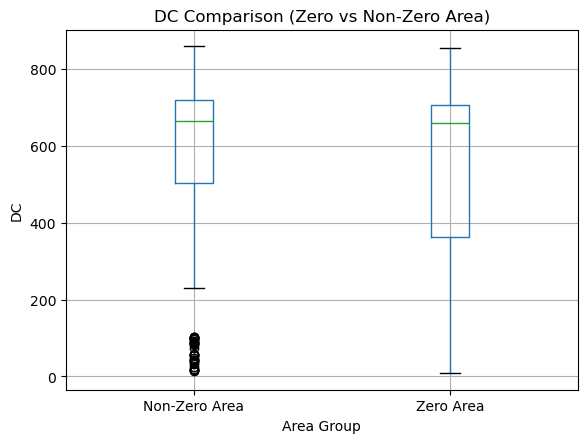

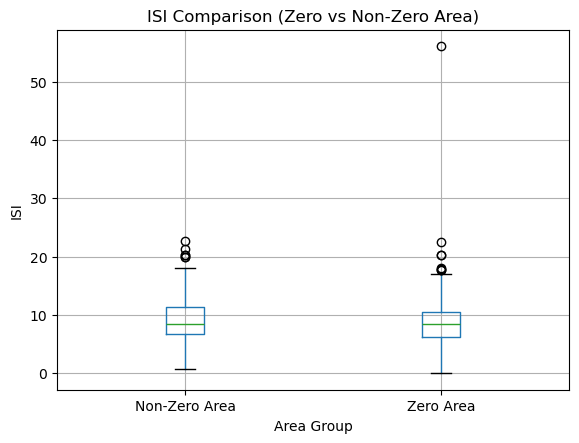

In [85]:
# creating grouping column
df['area_group'] = df['area'].apply(lambda x: 'Zero Area' if x == 0 else 'Non-Zero Area')

import matplotlib.pyplot as plt

for col in indices:
    df.boxplot(column=col, by='area_group')
    plt.title(f'{col} Comparison (Zero vs Non-Zero Area)')
    plt.suptitle("")
    plt.xlabel("Area Group")
    plt.ylabel(col)
    plt.show()

## Seasonal Wildfire Trend 

Wildfire timing patterns will be checked by examining wildfire frequency across months and days, as well as burned area trends by month. This helps identify possible seasonal patterns in wildfire activity.

#### Fires by Month

Which month recorded the highest number of wildfire events?

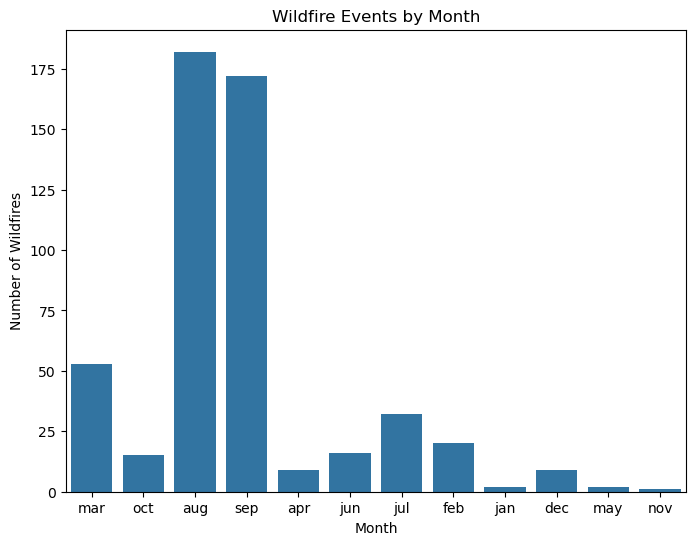

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='month')
plt.title('Wildfire Events by Month')
plt.xlabel('Month')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart above shows that wildfire events were not evenly distributed across the months. August and September recorded the highest number of wildfire events, while some months such as November, May, and January recorded very few wildfire occurrences. This pattern indicates that wildfire activity was more concentrated during certain periods of the year.

#### Insight

This indicates that wildfire activity may increase during specific seasons, particularly around late summer periods such as August and September. Environmental conditions during these months, such as higher temperatures and drier conditions, may contribute to increased wildfire occurrence.

### Fires by Day

What days recorded more wildfire events?

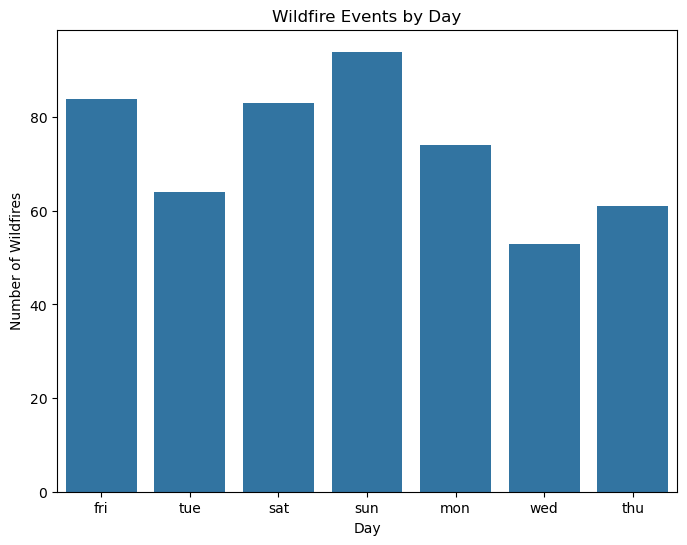

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='day')
plt.title('Wildfire Events by Day')
plt.xlabel('Day')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart shows variations in wildfire frequency across different days of the week. Sunday recorded the highest number of wildfire events, while Wednesday recorded the lowest. Although wildfire events occurred throughout the week, some days experienced slightly higher wildfire activity than others.

#### Insight

This indicates that wildfire occurrences may vary across the week, but the differences are not extremely large. The pattern suggests that wildfire activity is not strongly concentrated on a single day, as wildfire events were recorded consistently throughout the week.

#### Wildfire Severity by Month

What month experienced larger wildfire burned areas?

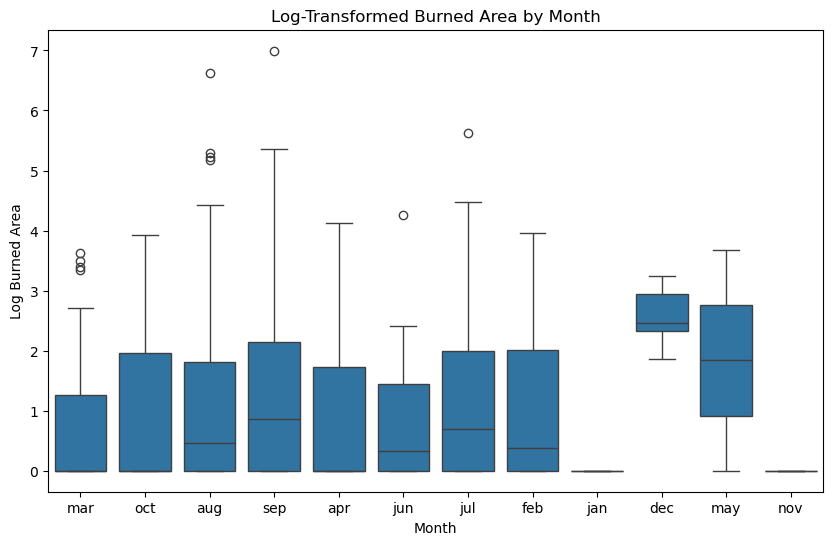

In [59]:
import matplotlib.pyplot as lt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned, x='month', y='area_log')
plt.title('Log-Transformed Burned Area by Month')
plt.xlabel('Month')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation
The box plot shows differences in log-transformed burned area across the months. Months such as September, July, and August recorded higher burned area values and greater variation compared to some other months. December also shows relatively higher median burned area values, although with fewer extreme values. In contrast, months like January and November recorded little or no burned area activity. The presence of outliers in some months indicates that a few wildfire events resulted in unusually large burned areas.

#### Insight

This indicates that wildfire severity varied across different months of the year. Months with higher burned area values and wider distributions may have experienced environmental conditions that supported larger wildfire spread. 

## Importance of Fire Weather Indices

In [60]:
df_cleaned[
    ["FFMC","DMC","DC","ISI","area_log"]
].corr()

,FFMC,DMC,DC,ISI,area_log
FFMC,1.000000,0.383641,0.332936,0.532083,0.047155
DMC,0.383641,1.000000,0.681741,0.304585,0.071648
DC,0.332936,0.681741,1.000000,0.228168,0.072025
ISI,0.532083,0.304585,0.228168,1.000000,-0.009467
area_log,0.047155,0.071648,0.072025,-0.009467,1.000000


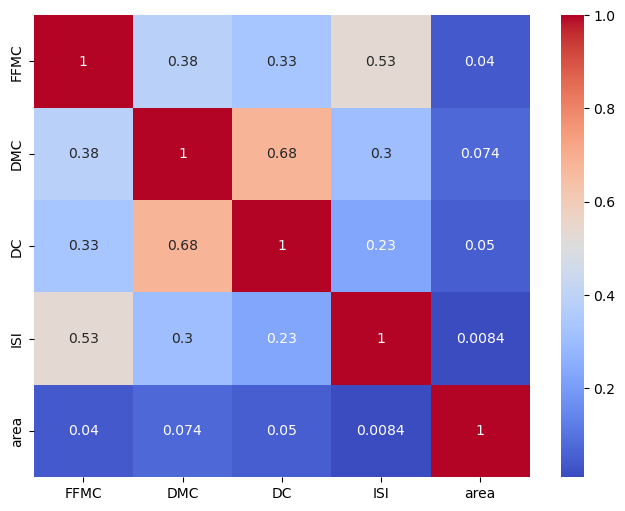

In [61]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_cleaned[
        ["FFMC","DMC","DC","ISI","area"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Interpretation

The heatmap shows that all fire weather indices have a positive but weak relationship with burned area. This means that as the index values increase, the burned area may also increase slightly. Among the four indices, DMC has the highest correlation (0.073), making it the most related to wildfire severity in this dataset. However, the relationship is still weak, which suggests that wildfire severity is not caused by one fire index alone but by a combination of different factors such as weather conditions and fire behaviour.

##  FEATURE ENGINEERING (Creating New Variables)

Feature engineering was carried out to create new variables that can help improve wildfire risk analysis and make patterns in the data easier to understand. The new features were created from existing weather and wildfire variables to help identify conditions linked to wildfire risk and fire severity.

### High Risk Condition Flag

This variable was created to identify weather conditions that may increase the chances of wildfire occurrence.

In [62]:
# Wildfire occurence is high risk if:
df_cleaned["high_risk"] = (
    (df_cleaned["temp"] >= 28) &
    (df_cleaned["wind"] >= 4) &
    (df_cleaned["RH"] <= 45))
df_cleaned[["temp", "wind", "RH", "high_risk"]].head()

,temp,wind,RH,high_risk
0,8.2,6.7,51,False
1,18.0,0.9,33,False
2,14.6,1.3,33,False
3,8.3,4.0,97,False
4,11.4,1.8,99,False


The high-risk wildfire condition feature was created using weather thresholds associated with Mediterranean wildfire behavior in Portugal.

A condition is classified as high risk when:
- temperature was at least 28°C and above,
- wind speed was at least 4 km/h and above,
- relative humidity was 45% or lower.

These thresholds were selected because hot temperatures, stronger winds, and low humidity can dry out vegetation and make wildfire spread more likely.

In [63]:
# High Risk Condtion Distribution

df_cleaned["high_risk"].value_counts()

high_risk
False    500
True      13
Name: count, dtype: int64

#### Interpretation
The distribution of the high-risk feature shows that most wildfire observations were classified as low risk, while only a small number met the high-risk condition criteria.

Out of 513 observations:
- 500 were classified as low risk
- 13 were classified as high risk

#### Insight
This suggests that extreme wildfire weather conditions were not very common in the dataset.

### Fire Size Category
This was created to group wildfire incidents into small and large fire categories based on the burned area. The median burned area was used as the classification threshold because the burned area data is highly skewed.

This feature improves interpretability by simplifying wildfire severity into meaningful categories that can be analyzed more easily.

In [64]:
# use of median because of the skewedness of the dataset
median_area = df_cleaned["area"].median()

In [65]:
# Fire Size Category of dataset
df_cleaned["fire_size"] = df_cleaned["area"].apply(
    lambda x: "Large Fire" if x > median_area else "Small Fire")
df_cleaned [["area", "fire_size"]].head()

,area,fire_size
0,0.0,Small Fire
1,0.0,Small Fire
2,0.0,Small Fire
3,0.0,Small Fire
4,0.0,Small Fire


In [66]:
# Fire Size Condtion Distribution

df_cleaned["fire_size"].value_counts()

fire_size
Small Fire    257
Large Fire    256
Name: count, dtype: int64

### Interpretation
Out of 513 observations:
- 257 were classified as Small Fire
- 256 were classified as Large Fire

This balanced distribution occurred because the median burned area was used as the classification threshold. 

### Insight
The result shows that the feature created a clear separation between small and large fires, making wildfire severity easier to analyse.

### Feature Engineering Summary

Two new features were created during this stage:
- High_risk → identifies weather conditions linked to wildfire risk
- Fire_size → groups wildfire incidents into small and large fires

These features help improve wildfire interpretation and can support future predictive modelling.

In [82]:
# Saving Updated Dataset With The newly created features

df_cleaned.to_csv("df_cleaned.csv", index=False)

## High-Risk Threshold Analysis

This section identifies the environmental and fire danger conditions under which larger wildfire events are more likely to occur. The aim is to establish practical threshold ranges that can support wildfire monitoring and early warning systems.

In [69]:
# High-risk humidity range
df_cleaned.groupby("fire_size")["RH"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,256.0,43.667969,15.277406,15.0,32.75,41.0,53.0,96.0
Small Fire,257.0,45.027237,17.372618,15.0,33.00,42.0,54.0,100.0


In [135]:
# High-risk Duff Moisture Code
high_dmc = df_cleaned.groupby("fire_size")["DMC"].describe()
high_dmc

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,256.0,114.267578,62.327903,3.2,82.625,111.45,141.125,291.3
Small Fire,257.0,107.723735,65.953976,1.1,51.300,104.20,142.400,290.0


In [136]:
# High-risk wind Speed
df_cleaned.groupby("fire_size")["wind"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,256.0,4.149609,1.903063,0.4,2.7,4.0,4.9,9.4
Small Fire,257.0,3.871984,1.676164,0.9,2.7,3.6,4.9,8.5


In [137]:
# High-risk drought code
df_cleaned.groupby("fire_size")["DC"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,256.0,568.169922,232.033893,15.3,479.325,664.35,721.4,860.6
Small Fire,257.0,530.214397,261.502998,7.9,376.600,664.50,706.7,855.3


In [138]:
# High-risk temperature range
df_cleaned.groupby("fire_size")["temp"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,256.0,19.242188,6.292007,2.2,15.9,20.1,23.4,33.3
Small Fire,257.0,18.534241,5.314918,4.2,15.4,18.6,21.9,32.4


### Practical Insight

The high-risk threshold analysis shows some practical patterns in wildfire severity.

For **Relative Humidity (RH)**, larger fires had a lower average humidity (**43.7%**) compared to smaller fires (**45.0%**). This suggests that wildfire severity tends to increase when humidity drops below **44%**, because dry air makes vegetation easier to burn.

For **DMC (Duff Moisture Code)**, larger fires had a higher average value (**114.3**) than smaller fires (**107.7**). This shows that wildfire severity increases when the forest experiences medium-term dryness, especially above **110**.

For **wind speed**, larger fires recorded a higher average (**4.15 km/h**) compared to smaller fires (**3.87 km/h**). This suggests that wildfire spread becomes more dangerous when wind speed rises above **4 km/h**.

For **Drought Code (DC)**, larger fires had a higher average (**568.2**) compared to smaller fires (**530.2**). This indicates that prolonged dry conditions above **560** may increase wildfire severity.

For **temperature**, larger fires had a slightly higher average (**19.2°C**) compared to smaller fires (**18.5°C**). This suggests wildfire severity tends to rise when temperatures move above **19°C**, especially when combined with low humidity and dry fuel conditions.

Overall, the results show that wildfire severity becomes more likely under **hotter, drier, and windier conditions**, especially when dryness levels in the forest remain high over time. These thresholds can help forest managers monitor conditions and act early before fires become severe.


#### Why These Variables Were Selected for Threshold Analysis

These variables were selected because, during the relationship analysis, they showed stronger links with wildfire severity compared to the other variables. Temperature, humidity, and wind showed noticeable patterns with burned area, while DMC and DC also showed strong dryness conditions linked to wildfire spread. Based on these findings, they were analysed further to identify the conditions where wildfires become more severe.

## MODELLING PREPARATION

In this section, the cleaned dataset was prepared for modelling. The target variable and feature columns were selected,and the data was split into training and testing sets.

In [87]:
# loading Cleaned Dataset new columns created inclusive

import pandas as pd
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log,high_risk,fire_size
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0,False,Small Fire
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0,False,Small Fire
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0,False,Small Fire
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0,False,Small Fire
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0,False,Small Fire


In [118]:
# Defining the Target Variable for the model
y = df_cleaned["fire_size"]

In [119]:
# Removing area, area_log columns,area_group, fire_size as it is the target variable to prevent data leakage during modeling

X = df_cleaned.drop(["area", "area_log", "fire_size"], axis=1)

In [120]:
#checking dataset for text object

X.dtypes

X              int64
Y              int64
month         object
day           object
FFMC         float64
DMC          float64
DC           float64
ISI          float64
temp         float64
RH             int64
wind         float64
rain         float64
high_risk       bool
dtype: object

In [125]:
# Converting text to Numbers By Encoding Categorical Variables

X = pd.get_dummies(X, drop_first=True)

#### Train_Test Split

The dataset was divided into training and testing sets. 
80% of the data was used for training the model, while 20% was reserved for testing.

In [126]:
# Spliting dataset into training data and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

#### Checking Dataset Shape

The shapes of the training and testing datasets were checked to confirm that the data was split correctly.

In [127]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (410, 28)
X_test shape: (103, 28)
y_train shape: (410,)
y_test shape: (103,)


### Modelling Preparation Summary

The dataset was prepared for machine learning by defining the feature and target variables and splitting the data into training and testing sets.

The output shows that the dataset was successfully divided into training and testing sets. The training data contains 410 rows, while the testing data contains 103 rows. Both datasets contain 28 feature columns for modelling.

## MODELLING PHASE

In [128]:
# Importing libraries

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np

### Building The Model

In [129]:
# Trainingg the Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Predict Wildfire_Size Category

In [130]:
y_pred = model.predict(X_test)

### Evaluation Of Model

In [131]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5922330097087378
              precision    recall  f1-score   support

  Large Fire       0.56      0.56      0.56        48
  Small Fire       0.62      0.62      0.62        55

    accuracy                           0.59       103
   macro avg       0.59      0.59      0.59       103
weighted avg       0.59      0.59      0.59       103



###### Model Evaluation Interpretation

The Decision Tree Classification model was used to predict whether a wildfire would be classified as a Small Fire or Large Fire based on environmental and weather conditions.

The model achieved an accuracy of 59%, which means meaning it was able to correctly classify wildfire size in about 6 out of every 10 cases.

For **Large Fire**, the model had a precision of 56% and a recall of 56%. This means the model is showing a moderate ability to identify larger wildfire events as compared to small fires.

For **Small Fire**, the model had a precision of 62% and a recall of 62%. This means it was more accurate in identifying smaller wildfire events.

The F1-scores for both classes were close (0.56 for Large Fire and 0.62 for Small Fire), showing that the model’s performance is fairly balanced across both categories.

Overall, the results suggest that wildfire size prediction is influenced by many factors, making it a challenging problem for the model to classify accurately.

## Model Performance

The Decision Tree model achieved an accuracy of **59%**, meaning it correctly classified wildfire size in a little over half of the test cases. 

The model performed better in identifying **Small Fires** with a recall of **62%**, compared to **Large Fires** with a recall of **56%**. This suggests that the model was more effective at detecting Small wildfire events.

The F1-scores for both classes were relatively close, showing that the model had a fairly balanced performance across the two categories.

Overall, the model shows moderate predictive ability, but the results indicate that wildfire severity is influenced by multiple factors, making prediction more complex. Further model improvement or testing with more advanced algorithms may help improve performance.

### Feature Importance Analysis

Feature importance was examined to identify the variables that contributed most to wildfire size prediction.

In [132]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Remove X and Y only from feature importance interpretation
importance_filtered = importance[
    ~importance['Feature'].isin(['X', 'Y'])
]

importance_filtered = importance_filtered.sort_values(
    by='Importance',
    ascending=False
)

importance_filtered

,Feature,Importance
7,RH,0.159092
3,DMC,0.120364
8,wind,0.118219
4,DC,0.094357
2,FFMC,0.093950
6,temp,0.088620
5,ISI,0.085213
26,day_tue,0.034835
21,month_sep,0.019463
27,day_wed,0.015425


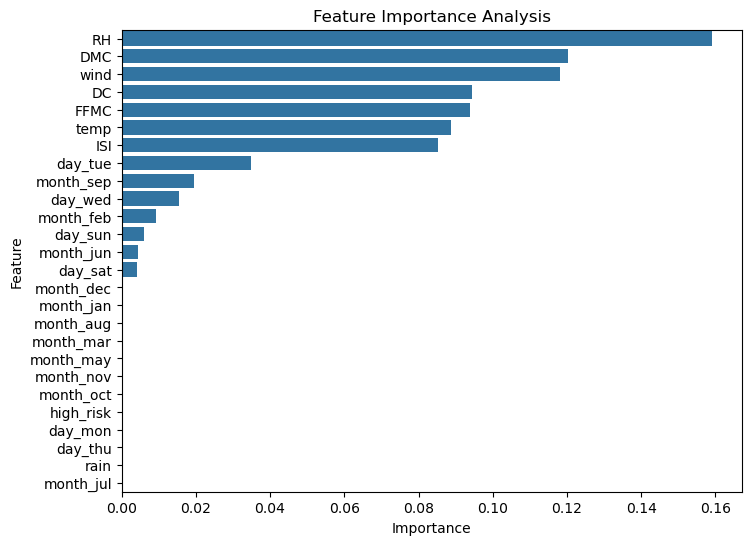

In [134]:
# plotting the feature variable according to their level of importance                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_filtered,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance Analysis")
plt.show()

### Feature Importance Interpretation

The feature importance analysis shows that **Relative Humidity (RH)** is the most important factor in predicting wildfire size. This means dry air plays a major role in how severe a wildfire can become.

The next important factors are **DMC**, **wind speed**, and **Drought Code (DC)**. This shows that dryness in the forest and strong wind conditions can increase wildfire severity.

Among the fire weather indices, **DMC** has the highest importance, followed by **DC**, **FFMC**, and **ISI**. This suggests that both short-term and long-term dry conditions affect wildfire behaviour.

Although **temperature** is still important, the result shows that wildfire severity depends more on dryness and wind than on heat alone.

This makes sense because in real life, low humidity dries up vegetation, high dryness levels make fuel easier to burn, and strong winds help fire spread faster.

Overall, the model shows that wildfire severity is caused by a combination of weather conditions and fire danger factors, not just one single factor.


# KEY INSIGHTS

**1. Wildfire severity increased under dry air conditions**
Relative Humidity (RH) was the most important factor in the model. The threshold analysis showed that larger fires occurred when humidity dropped below **44%**, showing that drier air creates conditions that make fire spread more easily.

**2. Medium-term dryness strongly influenced wildfire severity**
DMC was one of the strongest fire danger indicators in the analysis. Larger fires were observed when DMC values were above **110**, showing that dry fuel conditions over time increase wildfire intensity.

**3. Long-term dryness contributed to severe wildfire events**
Drought Code (DC) showed that larger fires were more common when values exceeded **560**, suggesting that prolonged dry conditions increase the amount of dry fuel available for burning.

**4. Wind speed increased wildfire spread**
The analysis showed that larger fires occurred when wind speed was above **4 km/h**. This confirms that stronger wind helps fire spread faster across affected areas.

**5. Temperature contributed to wildfire severity, but not alone**
Larger fires were more common when temperature rose above **19°C**. However, the analysis showed that temperature works together with low humidity and dry fuel conditions rather than acting alone.

**6. Wildfire severity is influenced by multiple factors working together**
The results showed that no single variable fully explains wildfire severity. Instead, wildfire behaviour depends on the combined effect of weather conditions, dryness levels, and fire danger indicators.

**7. Wildfire activity was higher during August and September**
Monthly analysis showed that wildfire activity and burned area were highest during August and September, indicating that wildfire risk increases during hotter and drier periods.

**8. Wildfire severity can be predicted, but remains complex**
The Decision Tree model achieved an accuracy of **59%**, showing moderate performance in classifying wildfire size. This suggests that while useful patterns exist, wildfire behaviour is still influenced by several interacting environmental and geographical factors.


# Recommedndations

**1. Strengthen wildfire monitoring with automated alert systems**
Forest managers should use meteorological stations with automatic warning systems to monitor critical wildfire conditions. Alerts should be triggered when **temperature rises above 19°C**, **relative humidity drops below 44%**, or **wind speed goes above 4 km/h**. This will help reduce delays in identifying and responding to wildfire risks.

**2. Monitor forest dryness by zones instead of treating the forest as one whole area**
Since **DMC** and **DC** can vary across different parts of the forest, managers should divide the forest into monitoring zones and track dryness levels separately. Areas where **DMC rises above 110** and **DC rises above 560** should be treated as high-risk zones and given more attention.

**3. Carry out fuel reduction when dryness reaches critical levels**
When **DMC exceeds 110** and **DC exceeds 560**, forest managers should clear dry leaves, dead trees, and excess vegetation to reduce fuel build-up. This can lower the chance of fires becoming larger and more severe.

**4. Increase patrols and preparedness during peak wildfire months**
Since wildfire activity was highest in **August and September**, and these periods often experience hotter, drier, and windier conditions, forest teams should increase patrols, strengthen emergency readiness, and improve fire prevention efforts during these months.

**5. Respond quickly to all fires, including small fires**
Small fires should not be ignored because under conditions of low humidity, high dryness, and strong wind, they can quickly grow into larger fires. Early detection and quick containment can prevent severe wildfire outbreaks.

**6. Improve emergency response during windy conditions**
When wind speed rises above **4 km/h**, emergency teams should remain on higher alert because stronger winds can increase the speed and spread of wildfire, making control more difficult.

**7. Use predictive models together with weather monitoring systems**
The predictive model showed useful wildfire patterns and can support early warning systems. Forest managers should combine predictive models with weather and dryness monitoring to improve early risk detection and decision-making.

**8. Strengthen wildfire prevention education in local communities**
Communities near forest areas in Portugal should be educated on practical wildfire prevention, such as safe agricultural burning, avoiding open flames during hot and dry periods, proper disposal of cigarette butts, reducing the use of spark-producing machinery, and reporting smoke or fire outbreaks early. This can help reduce human-caused wildfires.


# Conclusion

This project showed that wildfire severity is mainly influenced by a combination of weather conditions and fire danger factors. From the analysis, **low humidity, high Duff Moisture Code (DMC), high Drought Code (DC), stronger wind, and higher temperature** were the main conditions linked to larger wildfires.

The threshold analysis helped identify practical risk levels, showing that wildfire severity was higher when **humidity dropped below 44%**, **DMC went above 110**, **DC rose above 560**, **wind speed was above 4 km/h**, and **temperature was above 19°C**.

The Decision Tree model was also able to predict wildfire size with **59% accuracy**, showing that while wildfire patterns can be identified, wildfire behaviour is still complex and depends on several factors working together.

Overall, the project shows that understanding these conditions can help forest managers detect wildfire risks earlier, respond faster, and put better prevention measures in place.
